In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms.v2 as tfs
from torchvision import models
from tqdm import tqdm
import os
import zipfile
import random
import optuna

In [2]:
# import warnings
# warnings.simplefilter(action='ignore', category=Warning)

For reproducibility of results:

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

We can copy the directory to kaggle/working (because kaggle/input is available only for reading):

In [4]:
%cp -r /kaggle/input/competitions/platesv2 /kaggle/working

# 1. First look at the data

Our images are in a ZIP archive, so we'll use ZipFile to unzip it:

In [5]:
with zipfile.ZipFile('/kaggle/working/platesv2/plates.zip', 'r') as zip_obj:
   # extract all the contents of zip file in current directory
   zip_obj.extractall('/kaggle/working/')
    
print('After zip extraction:')
print(os.listdir('/kaggle/working/'))

After zip extraction:
['__MACOSX', 'platesv2', 'plates', '__notebook__.ipynb']


In [6]:
# root folder
data_root = '/kaggle/working/plates'

print(os.listdir(data_root))

['train', '.DS_Store', 'test']


.DS_Store - junk files from macOS.

Let's delete this file from all folders, as it will interfere with the formation of datasets.

In [7]:
for dir_path, dir_names, file_names in os.walk(data_root):
    for file_name in file_names:
        if file_name == '.DS_Store':
            path = os.path.join(dir_path, file_name)
            os.remove(path)
            print('The file has been deleted')

The file has been deleted
The file has been deleted
The file has been deleted
The file has been deleted
The file has been deleted


Let's take a look at a random image:

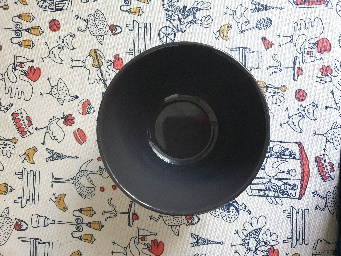

In [8]:
# we use cv2_imshow() from google.colab, because cv2.imshow()
# leads to kernel restarting
img_path = '/kaggle/working/plates/train/cleaned/0000.jpg'
img = cv2.imread(img_path)

cv2_imshow(img)

# 2. Data verification and EDA

**2.1 The balance of classes**

Let's check the size of the training and test samples:

In [9]:
train_path = '/kaggle/working/plates/train'
test_path = '/kaggle/working/plates/test'

# we have 2 classes
class_names = ['cleaned', 'dirty']

for class_name in class_names:
    print(f'Size of training set (class "{class_name}"):')
    print(len(os.listdir(os.path.join(train_path, class_name))))
    print()

print('Size of test set:')
print(len(os.listdir(os.path.join(test_path))))

Size of training set (class "cleaned"):
20

Size of training set (class "dirty"):
20

Size of test set:
744


Our training set is significantly smaller than the test set. However, the number of objects of the two classes in the training set is the same.

**2.2 Image sizes**

We can also check the size of images:

In [10]:
sizes = {}

# create paths for each set and class
train_cleaned_path = os.path.join(train_path, 'cleaned')
train_dirty_path = os.path.join(train_path, 'dirty')
paths = [train_cleaned_path, train_dirty_path, test_path]

# create lists of files for each set and class
images_train_cleaned = os.listdir(train_cleaned_path)
images_train_dirty = os.listdir(train_dirty_path)
images_test = os.listdir(test_path)
images = [images_train_cleaned, images_train_dirty, images_test]

for _dir, _list in zip(paths, images):
    for _img in _list:
        img = cv2.imread(os.path.join(_dir, _img))
        shape = img.shape
        sizes[shape] = sizes.get(shape, 0) + 1

sizes

{(256, 454, 3): 5,
 (341, 256, 3): 49,
 (256, 342, 3): 29,
 (256, 341, 3): 697,
 (455, 256, 3): 1,
 (454, 256, 3): 3}

Most images are the same size.

**2.3 Validation sample**

Now let's create a directory for the validation sample:

In [11]:
val_path = '/kaggle/working/plates/val'

# exist_ok=True, to avoid crashing if the folders already exist
os.makedirs(os.path.join(data_root, 'val', 'cleaned'), exist_ok=True)
os.makedirs(os.path.join(data_root, 'val', 'dirty'), exist_ok=True)

In [12]:
# move about 15% images to the new directory
for class_name in class_names:
    source_path = os.path.join(train_path, class_name)
    dest_path = os.path.join(val_path, class_name)
    files_list = os.listdir(source_path)
    
    val_img_names = random.sample(files_list, len(files_list) // 6)
    for val_img in val_img_names:
        os.rename(os.path.join(source_path, val_img),
                  os.path.join(dest_path, val_img))

Currently, the validation set only contains 6 images. This is insufficient for finding metrics and tuning hyperparameters. Therefore, we need to increase the validation set. We'll do it with augmentations.

Augmentations should be soft enough!

In [13]:
def validation_set_extension(class_names):
    transforms = tfs.Compose([tfs.RandomHorizontalFlip(p=0.5),
                              tfs.RandomVerticalFlip(p=0.5), 
                              tfs.RandomAffine(degrees=15),
                              # tfs.GaussianBlur(kernel_size=3),
                              tfs.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05)
                             ])

    # we also can use torchvision.transforms.v2.AutoAugment
    # transforms = tfs.AutoAugment()
    
    for class_name in class_names:
        path = os.path.join(val_path, class_name)
        files_list = os.listdir(path)
        for file in files_list:
            # creating 5 new images
            for i in range(5):
                img = Image.open(os.path.join(path, file))
                img_new = transforms(img)
                img_new.save(os.path.join(val_path, class_name, f'{file[:-4]}_{i}.jpg'))


validation_set_extension(class_names)

In [14]:
for class_name in class_names:
    print(f'Size of new training set (class "{class_name}"):')
    print(len(os.listdir(os.path.join(train_path, class_name))), '\n')

for class_name in class_names:
    print(f'Size of validation set (class "{class_name}"):')
    print(len(os.listdir(os.path.join(val_path, class_name))), '\n')

Size of new training set (class "cleaned"):
17 

Size of new training set (class "dirty"):
17 

Size of validation set (class "cleaned"):
18 

Size of validation set (class "dirty"):
18 



# 3. Creating a Dataset and Dataloader

We can use ImageFolder to create datasets, but it expects class folders within the root directory, so it's not suitable for a test set.

Therefore, we'll use a custom class.

As an experiment, we can set the parameter label_smoothing in CrossEntropyLoss so that the loss function does not penalize the model so much for strong false confidence.

In [15]:
class MyDataset(data.Dataset):
    def __init__(self, path, class_names, train=True, transform=None):
        self.path = path
        self.class_names = class_names
        self.train = train
        self.transform = transform
        
        # one-hot vectors
        self.targets = torch.eye(len(self.class_names))
        self.files = []

        # for train - get images and targets
        if self.train:
            self.length = 0
            for i, _dir in enumerate(self.class_names):
                path = os.path.join(self.path, _dir)
                list_files = os.listdir(path)
                self.length += len(list_files)
                # add tuple (path, class label)
                self.files.extend(map(lambda x: (os.path.join(path, x), i), list_files))
        # for test - get images and file names
        # we need file names to connect them to predictions
        else:
            list_files = os.listdir(path)
            self.files = [(os.path.join(path, i), i) for i in list_files]
            self.length = len(self.files)

    def __getitem__(self, item):
        if self.train:
            path_file, target = self.files[item]
            img = Image.open(path_file)
            y = self.targets[target]

            if self.transform:
                img = self.transform(img)
            return img, y

        else:
            path_file, name_file = self.files[item]
            img = Image.open(path_file)

            if self.transform:
                img = self.transform(img)
            return img, name_file

    def __len__(self):
        return self.length


# transforms for train - with augmentations
train_transforms = tfs.Compose([tfs.RandomResizedCrop((256, 256), scale=(0.7, 0.9)),
                                tfs.RandomHorizontalFlip(p=0.5),
                                tfs.RandomVerticalFlip(p=0.5),
                                # tfs.RandomErasing(0.2, scale=(0.01, 0.02)),
                                tfs.RandomAffine(degrees=15),
                                # tfs.GaussianBlur(kernel_size=3),
                                tfs.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                                tfs.ToImage(),
                                # tfs.Grayscale(),
                                # scale=True brings values to the range [0, 1]
                                tfs.ToDtype(torch.float32, scale=True),
                                # use ImageNet mean and standard deviation
                                tfs.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                                ])

# transforms for val and test - without augmentations
val_transforms = tfs.Compose([tfs.Resize((256, 256)),
                              tfs.ToImage(),
                              # tfs.Grayscale(),
                              tfs.ToDtype(torch.float32, scale=True),
                              tfs.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                             ])

d_train = MyDataset(train_path, class_names=class_names, train=True,
                    transform=train_transforms)
d_val = MyDataset(val_path, class_names=class_names, train=True,
                  transform=val_transforms)
d_test = MyDataset(test_path, class_names=class_names, train=False,
                   transform=val_transforms)

x, y = d_train[0]
print(x.shape, y.shape)

print(len(d_train))
print(len(d_val))
print(len(d_test))

torch.Size([3, 256, 256]) torch.Size([2])
34
36
744


In [16]:
batch_size = 64

train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True, drop_last=False)
val_data = data.DataLoader(d_val, batch_size=batch_size, shuffle=False, drop_last=False)
test_data = data.DataLoader(d_test, batch_size=batch_size, shuffle=False, drop_last=False)

X_batch, y_batch = next(iter(train_data))
print(X_batch.shape, y_batch.shape)

print(len(train_data))
print(len(val_data))
print(len(test_data))

torch.Size([34, 3, 256, 256]) torch.Size([34, 2])
1
1
12


Let's look at our images:

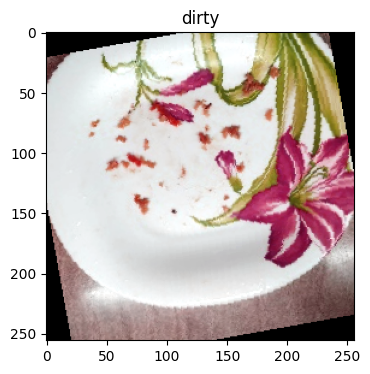

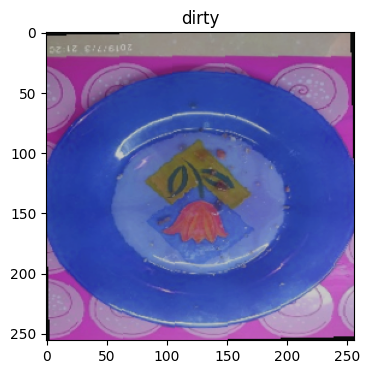

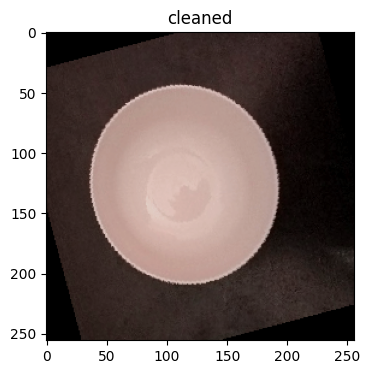

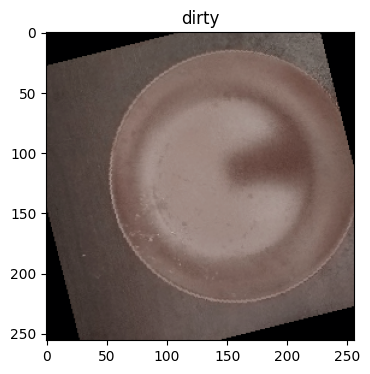

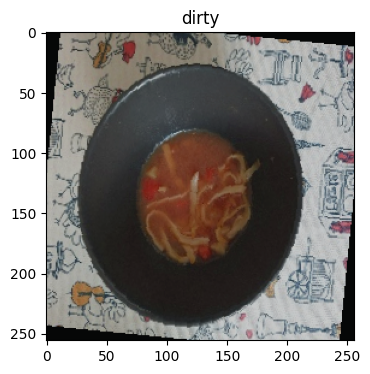

In [17]:
def show_img(input_tensor, input_target):
    # ImageNet mean and standard deviation
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for x, y in zip(input_tensor[:5], input_target[:5]):
        plt.figure(figsize=(4, 4))
        # we need to permute dims to display the image. Also, since we previously used
        # the mean and standard deviation for normalization, we need to perform the
        # inverse transformation
        x = x.permute(1, 2, 0).numpy() * std + mean
        # plt.imshow takes an image with RGB values (0-1 float or 0-255 int), so
        # we need to clip the range
        plt.imshow(x.clip(0, 1))
        # we can get the class using argmax
        plt.title(class_names[y.argmax()])
        # If there is an active figure, it will be updated and displayed before
        # the pause, and the GUI event loop (if any) will run during the pause
        plt.pause(0.001)


show_img(X_batch, y_batch)

# 4. Baseline

We will use GPU (T4 x 2) for training models. PyTorch here doesn't support GPU P100.

In [18]:
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

True


To start, we'll use a simple CNN. Obviously, it won't produce good results.

In [19]:
custom_cnn = nn.Sequential(nn.Conv2d(3, 32, 3, padding='same', bias=False),
                           nn.ReLU(),
                           nn.MaxPool2d(kernel_size=2),
                           nn.Conv2d(32, 64, 3, padding='same', bias=False),
                           nn.ReLU(),
                           nn.MaxPool2d(kernel_size=2), 
                           nn.Conv2d(64, 128, 3, padding='same', bias=False),
                           nn.ReLU(),
                           nn.MaxPool2d(kernel_size=2),
                           nn.Flatten(start_dim=1),
                           nn.Linear(128 * 32 * 32, 128),
                           nn.ReLU(),
                           nn.Linear(128, 2)
                          )

# transfer to device
custom_cnn = custom_cnn.to(device)

In [20]:
class Model_Trainer:
    def __init__(self, model, epochs=100, early_stopping_rounds=None,
                 optimizer=None, scheduler_params=None, logging=False):
        self.model = model
        self.epochs = epochs
        self.early_stopping_rounds = early_stopping_rounds
        self.optimizer = optimizer
        self.logging = logging
        
        # if we pass optimizer (for Optuna) - we use it
        if self.optimizer is None:
            self.optimizer=optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-5) 

        # if scheduler_params is None:
        #     self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=30, gamma=0.3)
        # else:
        #     self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, **scheduler_params)
            
        # lists for loss function and accuracy values
        self.loss_train_history = []
        self.accuracy_train = []
        self.loss_val_history = []   
        self.accuracy_val = []

        if self.early_stopping_rounds:
            self.best_score = 0
            self.counter_for_stopping = 0

    def train(self, train_data, val_data):
        # we optionally can use label_smoothing
        # loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
        loss_function = nn.CrossEntropyLoss()
        
        for _e in range(self.epochs):
            # checking stopping conditions
            if self.early_stopping_rounds:
                if _e > 0 and accuracy_val > self.best_score:
                    self.best_score = accuracy_val
                    self.counter_for_stopping = 0
                    # best model parameters
                    self.best_params = self.model.state_dict()
                elif _e > 0:
                    self.counter_for_stopping += 1
                    if self.counter_for_stopping == self.early_stopping_rounds:
                        print(f'Early stopping on epoch {_e + 1}')
                        break

            # training
            self.model.train()
            # variables for calculating the moving average and accuracy
            loss_mean_train = 0
            correct_train = 0
            # we look at the batch size, since the last batch may be
            # smaller than the others
            n_batch_train = 0
            
            for x_train, y_train in train_data:
                # transfer to device
                x_train = x_train.to(device)
                y_train = y_train.to(device)
                
                y_pred = self.model(x_train)
                loss_train = loss_function(y_pred, y_train)
    
                self.optimizer.zero_grad()
                loss_train.backward()
                self.optimizer.step()
    
                loss_mean_train += loss_train.item()
                y_train = y_train.argmax(dim=1)
                y_pred = y_pred.argmax(dim=1)
                correct_train += (y_pred == y_train).sum().item()
                n_batch_train += y_train.shape[0]
     
            loss_mean_train /= len(train_data)
            self.loss_train_history.append(loss_mean_train)
            accuracy_train = correct_train / n_batch_train
            self.accuracy_train.append(accuracy_train)
            if self.logging:
                print(f'Epoch [{_e + 1}/{self.epochs}], loss_mean_train={loss_mean_train:.3f}')
    
            # evaluation
            self.model.eval()
            # variables for calculating the moving average and accuracy
            loss_mean_val = 0
            correct_val = 0
            n_batch_val = 0
            
            for x_val, y_val in val_data:
                x_val = x_val.to(device)
                y_val = y_val.to(device)
                
                with torch.no_grad():
                    y_pred_val = self.model(x_val)
                    loss_val = loss_function(y_pred_val, y_val)
                
                loss_mean_val += loss_val.item()
                y_val = y_val.argmax(dim=1)
                y_pred_val = y_pred_val.argmax(dim=1)
                correct_val += (y_pred_val == y_val).sum().item()
                n_batch_val += y_val.shape[0]
    
            loss_mean_val /= len(val_data)
            self.loss_val_history.append(loss_mean_val)
            accuracy_val = correct_val / n_batch_val
            self.accuracy_val.append(accuracy_val)
            if self.logging:
                print(f'Epoch [{_e + 1}/{self.epochs}], loss_mean_val={loss_mean_val:.3f}, accuracy_val={accuracy_val}')

            # self.scheduler.step()

        return self.model, accuracy_val
            
    def plot_graphs(self):
        fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
        
        ax[0].plot(self.loss_train_history, label='train_loss')
        ax[0].plot(self.loss_val_history, label='val_loss')
        ax[0].legend(loc='best')
        ax[0].grid()

        ax[1].plot(self.accuracy_train, label='train_accuracy')
        ax[1].plot(self.accuracy_val, label='val_accuracy')
        ax[1].legend(loc='best')
        ax[1].grid()

    def make_inference(self, test_data, use_best_model=True, show_img=True):
        if use_best_model:
            self.model.load_state_dict(self.best_params)

        # arrays for results
        test_pred_proba = torch.tensor([])
        test_file_names = []        
    
        test_tqdm = tqdm(test_data, leave=True)
        # we get image and file name
        for x_test, x_file_name in test_tqdm:
            x_test = x_test.to(device)
            with torch.no_grad():
                y_pred = self.model(x_test)
                # we can get probabilities for analysis
                y_pred_proba = y_pred.softmax(dim=1).cpu()
                
            test_pred_proba = torch.cat([test_pred_proba, y_pred_proba], dim=0)
            test_file_names.extend(x_file_name)             
    
        if show_img:
            # prediction visualization
            # ImageNet mean and standard deviation
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
    
            for x, y in zip(x_test.cpu()[:5], y_pred_proba[:5]):
                x = x.permute(1, 2, 0).numpy() * std + mean
                plt.figure(figsize=(4, 4))
                plt.imshow(x.clip(0, 1))
                plt.title(f'{"cleaned" if y.argmax() < 0.5 else "dirty"}: {y.max().item()}')
                plt.pause(0.001)

        # return probabilities of classes
        return test_pred_proba, test_file_names

In [21]:
cnn_trainer = Model_Trainer(custom_cnn, epochs=100, early_stopping_rounds=30, logging=True)
custom_cnn, custom_cnn_accuracy = cnn_trainer.train(train_data, val_data)

Epoch [1/100], loss_mean_train=0.690
Epoch [1/100], loss_mean_val=1.179, accuracy_val=0.5
Epoch [2/100], loss_mean_train=1.001
Epoch [2/100], loss_mean_val=1.596, accuracy_val=0.5
Epoch [3/100], loss_mean_train=1.658
Epoch [3/100], loss_mean_val=1.059, accuracy_val=0.5
Epoch [4/100], loss_mean_train=1.017
Epoch [4/100], loss_mean_val=0.737, accuracy_val=0.4722222222222222
Epoch [5/100], loss_mean_train=0.685
Epoch [5/100], loss_mean_val=0.823, accuracy_val=0.5
Epoch [6/100], loss_mean_train=0.767
Epoch [6/100], loss_mean_val=0.827, accuracy_val=0.5
Epoch [7/100], loss_mean_train=0.764
Epoch [7/100], loss_mean_val=0.788, accuracy_val=0.5
Epoch [8/100], loss_mean_train=0.749
Epoch [8/100], loss_mean_val=0.747, accuracy_val=0.3611111111111111
Epoch [9/100], loss_mean_train=0.712
Epoch [9/100], loss_mean_val=0.729, accuracy_val=0.3611111111111111
Epoch [10/100], loss_mean_train=0.706
Epoch [10/100], loss_mean_val=0.739, accuracy_val=0.5
Epoch [11/100], loss_mean_train=0.668
Epoch [11/100],

In [22]:
cnn_trainer.best_score

0.5

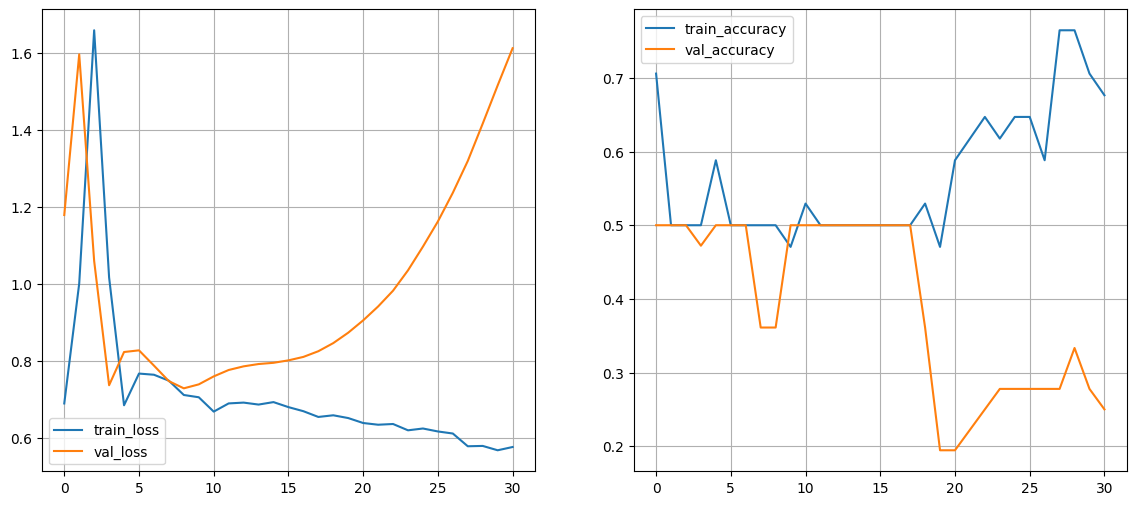

In [23]:
cnn_trainer.plot_graphs()

100%|██████████| 12/12 [00:02<00:00,  4.12it/s]


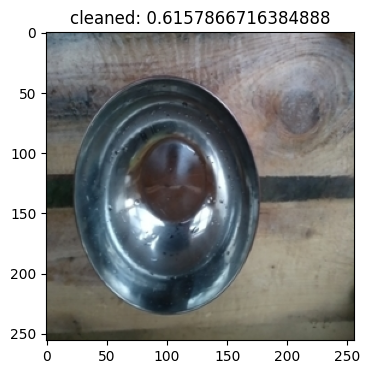

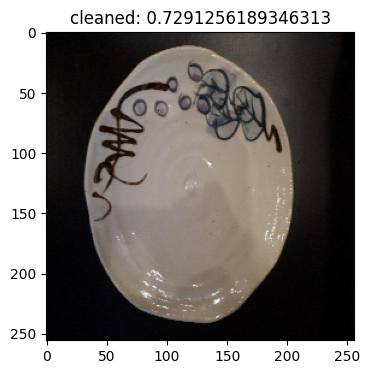

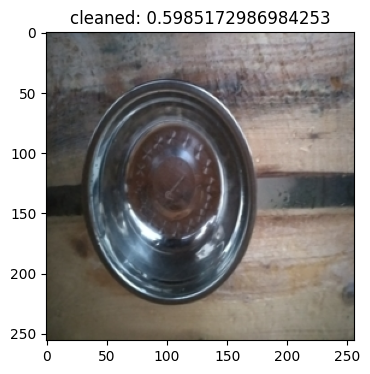

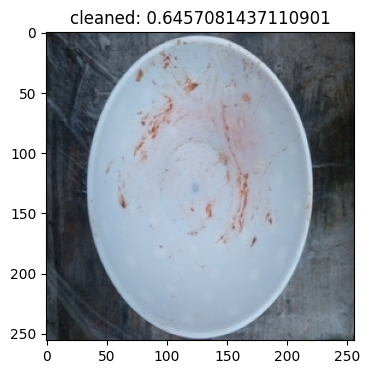

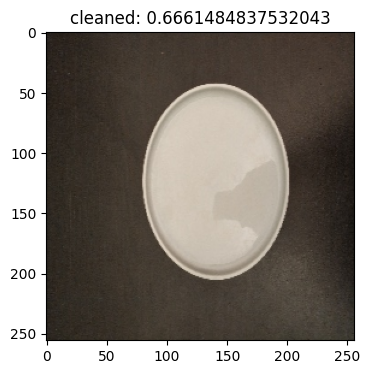

array(['cleaned', 'dirty'], dtype='<U7')

In [24]:
y_proba_cnn, file_names_cnn = cnn_trainer.make_inference(test_data, use_best_model=True)
y_pred_cnn = y_proba_cnn.argmax(dim=1).numpy()
# mapping to our class labels
test_pred_cnn = np.where(y_pred_cnn < 0.5, 'cleaned', 'dirty')

# checking values
np.unique(test_pred_cnn)

In [25]:
def make_df(test_pred, file_names):
    submission_df = pd.DataFrame({'id': file_names, 'label': test_pred})
    submission_df['id'] = submission_df['id'].str.replace('.jpg', '')
    submission_df = submission_df.sort_values('id')
    return submission_df


submission_cnn = make_df(test_pred_cnn, file_names_cnn)

submission_cnn.head()

,id,label
594,0000,dirty
255,0001,cleaned
538,0002,cleaned
640,0003,cleaned
616,0004,dirty


In [26]:
submission_cnn.to_csv('submission_cnn.csv', index=False)

We have the best accuracy = 0.65322 with this simple model.

# 5. ML and scoring

**5.1 VGG-19**

In [27]:
vgg = models.vgg19_bn(weights='DEFAULT')

# vgg.classifier - FC layers
vgg.classifier

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 194MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [28]:
vgg_weights = models.VGG19_Weights.DEFAULT
# VGG preprocessing operations
vgg_transforms = vgg_weights.transforms()

vgg_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

The Model_Trainer class implements the early_stopping interface, but using it in Optuna with Pruner is difficult (the current code needs to be rewritten because we only use one epoch at a time, in which case Model_Trainer doesn't save the best_score). It would be more reasonable to return the best_score value in the function rather than the accuracy. This could be improved.

We don't use regularization, since standard architectures have dropout or BN.

In [29]:
# def objective(trial):
#     optimizer_name = trial.suggest_categorical('optimizer_name', ['Adam', 'SGD'])
#     lr = trial.suggest_float('lr', 1e-4, 1e-3)
    
#     momentum = None
#     amsgrad = None
#     if optimizer_name == 'SGD':
#         momentum = trial.suggest_float('momentum', 0.8, 0.99)
#     elif optimizer_name == 'Adam':
#         amsgrad = trial.suggest_categorical('amsgrad', [True, False])

#     # scheduler parameters
#     # scheduler_params = {'step_size': trial.suggest_int('step_size', 10, 40, step=10),
#     #                     'gamma': trial.suggest_float('gamma', 0.1, 0.9)}   

#     # model creation
#     vgg = models.vgg19_bn(weights='DEFAULT')
#     # disable grad for all conv layers (vgg.features - conv layers)
#     for layer in vgg.features:
#         layer.requires_grad = False

#     # the number of classes should be changed from 1000 to 2 (vgg.classifier - FC layers)
#     vgg.classifier[-1] = nn.Linear(vgg.classifier[-1].in_features, 2, bias=True)
#     vgg = vgg.to(device)

#     if optimizer_name == 'Adam':
#         vgg_trainer = Model_Trainer(vgg, epochs=1, early_stopping_rounds=False, logging=False,
#                                     optimizer=optim.Adam(vgg.parameters(), lr=lr, amsgrad=amsgrad))
#     elif optimizer_name == 'SGD':
#          vgg_trainer = Model_Trainer(vgg, epochs=1, early_stopping_rounds=False, logging=False,
#                                      optimizer=optim.SGD(vgg.parameters(), lr=lr,  momentum=momentum))

#     epochs = 30
#     for _e in range(1, epochs + 1):
#         vgg, vgg_accuracy = vgg_trainer.train(train_data, val_data)

#         # passes the intermediate accuracy value to Optuna, associating it with the current step number (epoch)
#         trial.report(vgg_accuracy, _e)
        
#         # early stop if worst result
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
            
#     return vgg_accuracy    


# study = optuna.create_study(direction='maximize', study_name='VGG-19',
#                             # the first 10 trials will never be terminated, even if they have bad results
#                             # the first 10 epochs of each trial are also not checked for pruning (even after the 10th trial)
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
#                            )
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# vgg_optuna_score = study.best_value
# vgg_optuna_params = study.best_params

In [30]:
# vgg_optuna_params

In [31]:
params = {'optimizer_name': 'Adam', 'lr': 0.0008656075032395167, 'amsgrad': True}

vgg = models.vgg19_bn(weights='DEFAULT')
for layer in vgg.features:
        layer.requires_grad = False

vgg.classifier[-1] = nn.Linear(vgg.classifier[-1].in_features, 2, bias=True)
vgg = vgg.to(device)

vgg_trainer = Model_Trainer(vgg, epochs=400, early_stopping_rounds=100,
                            optimizer=optim.Adam(vgg.parameters(), 0.0008656075032395167, amsgrad=True),
                            logging=True)
vgg, vgg_accuracy = vgg_trainer.train(train_data, val_data)

Epoch [1/400], loss_mean_train=0.682
Epoch [1/400], loss_mean_val=0.687, accuracy_val=0.6111111111111112
Epoch [2/400], loss_mean_train=0.656
Epoch [2/400], loss_mean_val=6.318, accuracy_val=0.5
Epoch [3/400], loss_mean_train=8.711
Epoch [3/400], loss_mean_val=2.526, accuracy_val=0.5
Epoch [4/400], loss_mean_train=0.362
Epoch [4/400], loss_mean_val=0.252, accuracy_val=0.9444444444444444
Epoch [5/400], loss_mean_train=0.697
Epoch [5/400], loss_mean_val=5.202, accuracy_val=0.6111111111111112
Epoch [6/400], loss_mean_train=0.314
Epoch [6/400], loss_mean_val=20.699, accuracy_val=0.6111111111111112
Epoch [7/400], loss_mean_train=0.171
Epoch [7/400], loss_mean_val=41.038, accuracy_val=0.6666666666666666
Epoch [8/400], loss_mean_train=0.083
Epoch [8/400], loss_mean_val=42.559, accuracy_val=0.6666666666666666
Epoch [9/400], loss_mean_train=0.555
Epoch [9/400], loss_mean_val=170.403, accuracy_val=0.5833333333333334
Epoch [10/400], loss_mean_train=0.495
Epoch [10/400], loss_mean_val=406.703, acc

In [32]:
vgg_trainer.best_score

0.9444444444444444

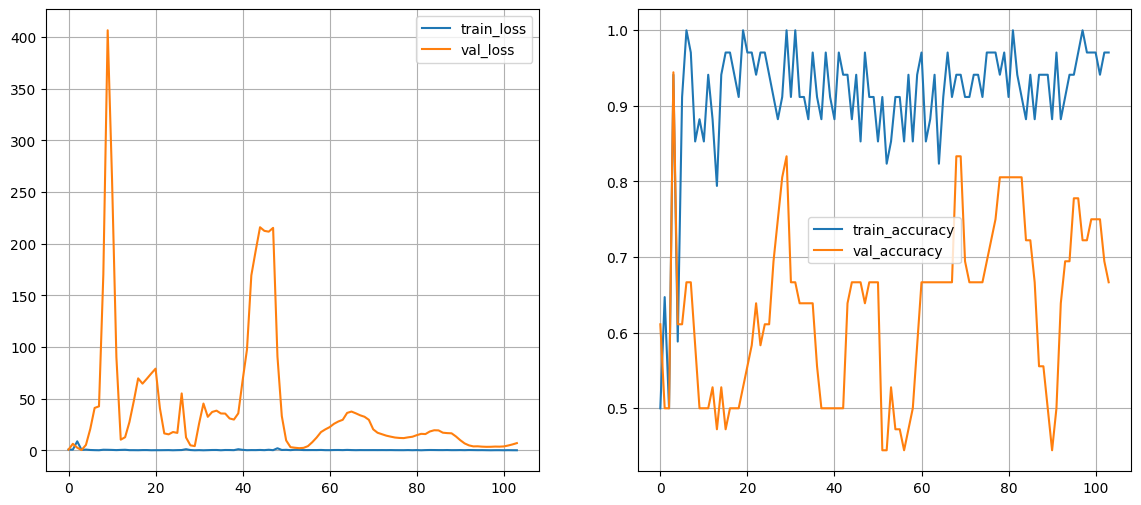

In [33]:
vgg_trainer.plot_graphs()

100%|██████████| 12/12 [00:08<00:00,  1.40it/s]


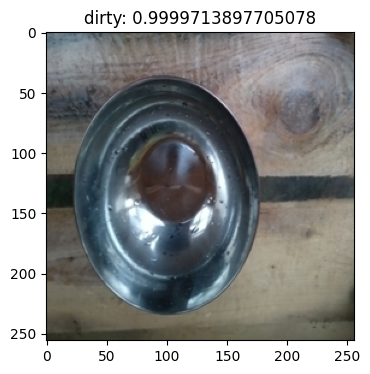

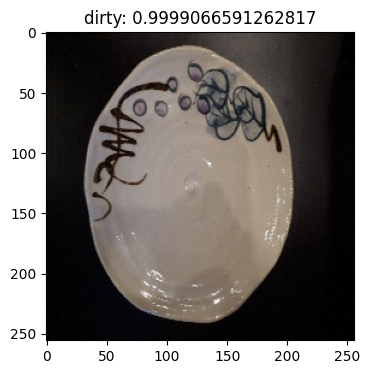

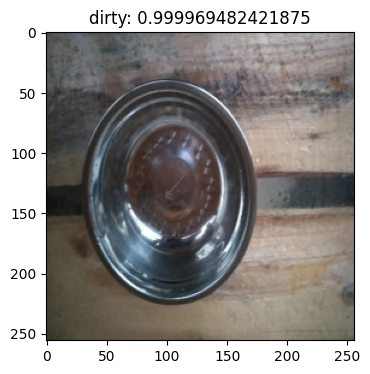

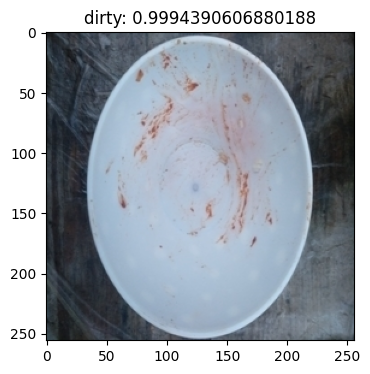

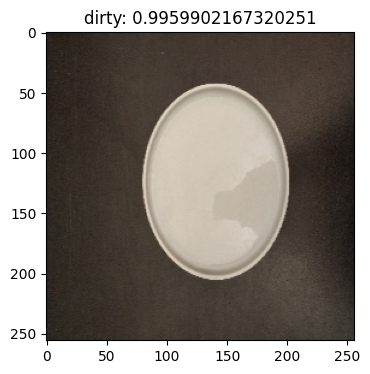

,id,label
594,0000,dirty
255,0001,dirty
538,0002,dirty
640,0003,dirty
616,0004,dirty


In [34]:
y_proba_vgg, file_names_vgg = vgg_trainer.make_inference(test_data, use_best_model=True)
y_pred_vgg = y_proba_vgg.argmax(dim=1).numpy()
# mapping to our class labels
test_pred_vgg = np.where(y_pred_vgg < 0.5, 'cleaned', 'dirty')

submission_vgg = make_df(test_pred_vgg, file_names_vgg)

submission_vgg.head()

In [35]:
submission_vgg.to_csv('submission_vgg.csv', index=False)

We have the best accuracy = 0.89381 with VGG-19 with BN.

**5.2 ResNet-18**

In [36]:
resnet_18 = models.resnet18(weights='DEFAULT')

# resnet_18.fc - one FC layer
resnet_18.fc

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Linear(in_features=512, out_features=1000, bias=True)

In [37]:
resnet_18_weights = models.ResNet18_Weights.DEFAULT
# ResNet preprocessing operations
resnet_18_transforms = resnet_18_weights.transforms()

resnet_18_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

We can try fine-tuning - changing the gradients in the last convolutional layers.

When fine-tuning, the learning rate should be small!

In [38]:
# def objective(trial):
#     optimizer_name = trial.suggest_categorical('optimizer_name', ['Adam', 'SGD'])
#     lr = trial.suggest_float('lr', 1e-5, 1e-3)
    
#     momentum = None
#     amsgrad = None
#     if optimizer_name == 'SGD':
#         momentum = trial.suggest_float('momentum', 0.8, 0.99)
#     elif optimizer_name == 'Adam':
#         amsgrad = trial.suggest_categorical('amsgrad', [True, False])

#     # scheduler parameters
#     # scheduler_params = {'step_size': trial.suggest_int('step_size', 10, 40, step=10),
#     #                     'gamma': trial.suggest_float('gamma', 0.1, 0.9)}
    
#     n_hidden = trial.suggest_categorical('n_hidden', [512, 1024, 2048])

#     # model creation
#     resnet_18 = models.resnet18(weights='DEFAULT')
#     # disable grad for all layers
#     resnet_18.requires_grad = False
#     # resnet_18.layer4[1] - the last BasicBlock in the model
#     resnet_18.layer4[1].requires_grad = True
    
#     # we need to get 2 classes output instead 1000 (resnet_18.fc - one FC layer)
#     # we can also add FC layers
#     n_features = resnet_18.fc.in_features
#     resnet_18.fc = nn.Sequential(nn.Linear(n_features, n_hidden, bias=False),
#                                  nn.BatchNorm1d(n_hidden),
#                                  nn.ELU(),
#                                  nn.Linear(n_hidden, 2, bias=True)
#                                 )
#     # we need to enable grad for FC layers
#     resnet_18.fc.requires_grad = True
#     resnet_18 = resnet_18.to(device)

#     if optimizer_name == 'Adam':
#         resnet_18_trainer = Model_Trainer(resnet_18, epochs=1, early_stopping_rounds=False, logging=False,
#                                           optimizer=optim.Adam(resnet_18.parameters(), lr=lr, amsgrad=amsgrad))
#     elif optimizer_name == 'SGD':
#          resnet_18_trainer = Model_Trainer(resnet_18, epochs=1, early_stopping_rounds=False, logging=False,
#                                            optimizer=optim.SGD(resnet_18.parameters(), lr=lr, momentum=momentum))

#     epochs = 30
#     for _e in range(1, epochs + 1):
#         resnet_18, resnet_18_accuracy = resnet_18_trainer.train(train_data, val_data)

#         # passes the intermediate accuracy value to Optuna, associating it with the current step number (epoch)
#         trial.report(resnet_18_accuracy, _e)
        
#         # early stop if worst result
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
            
#     return resnet_18_accuracy


# study = optuna.create_study(direction='maximize', study_name='ResNet-18',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
#                            )
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# resnet_18_optuna_score = study.best_value
# resnet_18_optuna_params = study.best_params

In [39]:
# resnet_18_optuna_params

In [40]:
params = {'optimizer_name': 'Adam', 'lr': 0.0003720380562412634, 'amsgrad': False, 'n_hidden': 2048}

resnet_18 = models.resnet18(weights='DEFAULT')
resnet_18.requires_grad = False
resnet_18.layer4[1].requires_grad = True

n_features = resnet_18.fc.in_features
resnet_18.fc = nn.Sequential(nn.Linear(n_features, 2048, bias=False),
                             nn.BatchNorm1d(2048),
                             nn.ELU(),
                             nn.Linear(2048, 2, bias=True)
                            )
resnet_18.fc.requires_grad = True
resnet_18 = resnet_18.to(device)

resnet_18_trainer = Model_Trainer(resnet_18, epochs=400, early_stopping_rounds=100,
                                  optimizer=optim.Adam(resnet_18.parameters(), lr=0.0003720380562412634, amsgrad=False),
                                  logging=True)
resnet_18, resnet_18_accuracy = resnet_18_trainer.train(train_data, val_data)

Epoch [1/400], loss_mean_train=0.576
Epoch [1/400], loss_mean_val=1.129, accuracy_val=0.5
Epoch [2/400], loss_mean_train=0.244
Epoch [2/400], loss_mean_val=1.203, accuracy_val=0.5
Epoch [3/400], loss_mean_train=0.119
Epoch [3/400], loss_mean_val=1.666, accuracy_val=0.5277777777777778
Epoch [4/400], loss_mean_train=0.077
Epoch [4/400], loss_mean_val=1.584, accuracy_val=0.6388888888888888
Epoch [5/400], loss_mean_train=0.019
Epoch [5/400], loss_mean_val=1.562, accuracy_val=0.8333333333333334
Epoch [6/400], loss_mean_train=0.128
Epoch [6/400], loss_mean_val=1.130, accuracy_val=0.7777777777777778
Epoch [7/400], loss_mean_train=0.007
Epoch [7/400], loss_mean_val=0.825, accuracy_val=0.75
Epoch [8/400], loss_mean_train=0.017
Epoch [8/400], loss_mean_val=0.641, accuracy_val=0.6944444444444444
Epoch [9/400], loss_mean_train=0.003
Epoch [9/400], loss_mean_val=0.538, accuracy_val=0.6944444444444444
Epoch [10/400], loss_mean_train=0.001
Epoch [10/400], loss_mean_val=0.465, accuracy_val=0.722222222

In [41]:
resnet_18_trainer.best_score

0.8333333333333334

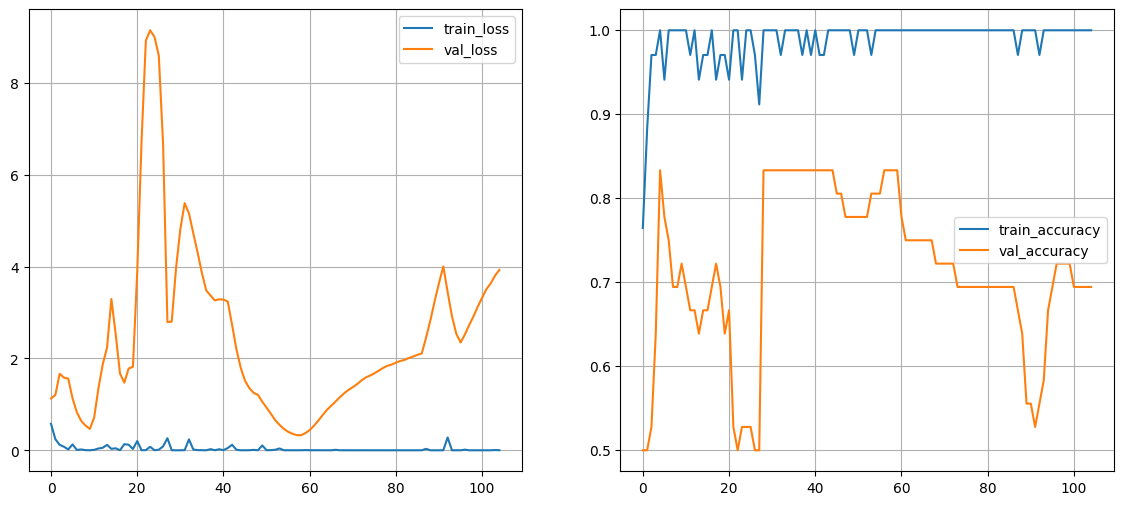

In [42]:
resnet_18_trainer.plot_graphs()

100%|██████████| 12/12 [00:02<00:00,  4.02it/s]


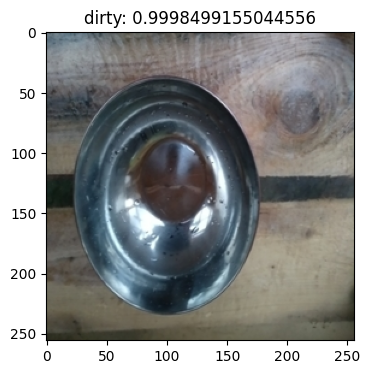

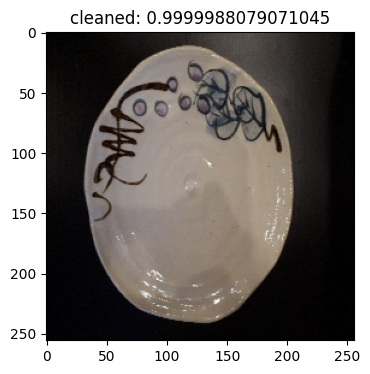

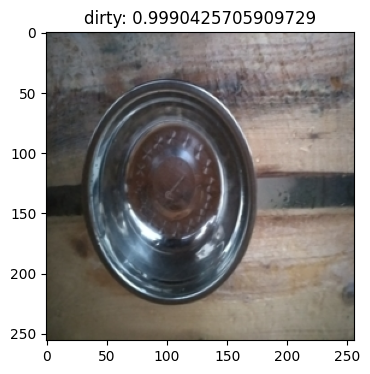

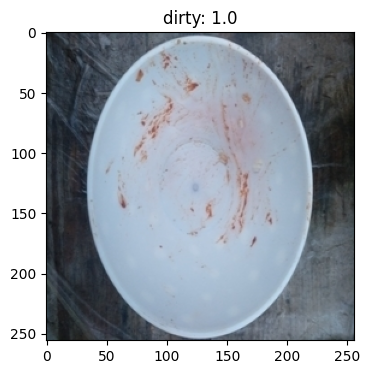

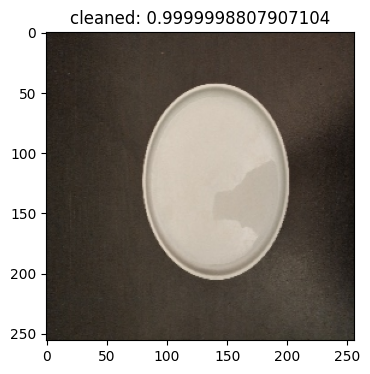

,id,label
594,0000,dirty
255,0001,dirty
538,0002,dirty
640,0003,dirty
616,0004,dirty


In [43]:
y_proba_resnet_18, file_names_resnet_18 = resnet_18_trainer.make_inference(test_data, use_best_model=True)
y_pred_resnet_18 = y_proba_resnet_18.argmax(dim=1).numpy()
# mapping to our class labels
test_pred_resnet_18 = np.where(y_pred_resnet_18 < 0.5, 'cleaned', 'dirty')

submission_resnet_18 = make_df(test_pred_resnet_18, file_names_resnet_18)

submission_resnet_18.head()

In [44]:
submission_resnet_18.to_csv('submission_resnet_18.csv', index=False)

We have the best accuracy = 0.89381 with ResNet-18.

**5.3 ResNet-50**

In [45]:
resnet_50 = models.resnet50(weights='DEFAULT')

# resnet_50.fc - one FC layer
resnet_50.fc

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Linear(in_features=2048, out_features=1000, bias=True)

In [46]:
resnet_50_weights = models.ResNet50_Weights.DEFAULT
# ResNet preprocessing operations
resnet_50_transforms = resnet_50_weights.transforms()

resnet_50_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [47]:
# def objective(trial):
#     optimizer_name = trial.suggest_categorical('optimizer_name', ['Adam', 'SGD'])
#     lr = trial.suggest_float('lr', 1e-5, 1e-3)
    
#     momentum = None
#     amsgrad = None
#     if optimizer_name == 'SGD':
#         momentum = trial.suggest_float('momentum', 0.8, 0.99)
#     elif optimizer_name == 'Adam':
#         amsgrad = trial.suggest_categorical('amsgrad', [True, False])

#     # scheduler parameters
#     # scheduler_params = {'step_size': trial.suggest_int('step_size', 10, 40, step=10),
#     #                     'gamma': trial.suggest_float('gamma', 0.1, 0.9)}   

#     n_hidden = trial.suggest_categorical('n_hidden', [512, 1024, 2048])    

#     # model creation
#     resnet_50 = models.resnet50(weights='DEFAULT')
#     # disable grad for all layers
#     resnet_50.requires_grad = False
#     # resnet_50.layer4[1] - the last BottleneckBlock in the model
#     resnet_50.layer4[1].requires_grad = True
    
#     # we need to get 2 classes output instead 1000 (resnet_50.fc - one FC layer)
#     # we can also add FC layers
#     n_features = resnet_50.fc.in_features
#     resnet_50.fc = nn.Sequential(nn.Linear(n_features, n_hidden, bias=False),
#                                  nn.BatchNorm1d(n_hidden),
#                                  nn.ELU(),
#                                  nn.Linear(n_hidden, 2, bias=True)
#                                 )
#     # we need to enable grad for FC layer
#     resnet_50.fc.requires_grad = True
#     resnet_50 = resnet_50.to(device)

#     if optimizer_name == 'Adam':
#         resnet_50_trainer = Model_Trainer(resnet_50, epochs=1, early_stopping_rounds=False, logging=False,
#                                           optimizer=optim.Adam(resnet_50.parameters(), lr=lr, amsgrad=amsgrad))
#     elif optimizer_name == 'SGD':
#          resnet_50_trainer = Model_Trainer(resnet_50, epochs=1, early_stopping_rounds=False, logging=False,
#                                            optimizer=optim.SGD(resnet_50.parameters(), lr=lr, momentum=momentum))

#     epochs = 30
#     for _e in range(1, epochs + 1):
#         resnet_50, resnet_50_accuracy = resnet_50_trainer.train(train_data, val_data)

#         # passes the intermediate accuracy value to Optuna, associating it with the current step number (epoch)
#         trial.report(resnet_50_accuracy, _e)
        
#         # early stop if worst result
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
            
#     return resnet_50_accuracy


# study = optuna.create_study(direction='maximize', study_name='ResNet-50',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
#                            )
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# resnet_50_optuna_score = study.best_value
# resnet_50_optuna_params = study.best_params

In [48]:
# resnet_50_optuna_params

In [49]:
params = {'optimizer_name': 'Adam', 'lr': 0.00024884072286350404, 'amsgrad': True, 'n_hidden': 512}

resnet_50 = models.resnet50(weights='DEFAULT')
resnet_50.requires_grad = False
resnet_50.layer4[1].requires_grad = True

n_features = resnet_50.fc.in_features
resnet_50.fc = nn.Sequential(nn.Linear(n_features, 512, bias=False),
                             nn.BatchNorm1d(512),
                             nn.ELU(),
                             nn.Linear(512, 2, bias=True)
                            )
resnet_50.fc.requires_grad = True
resnet_50 = resnet_50.to(device)

resnet_50_trainer = Model_Trainer(resnet_50, epochs=400, early_stopping_rounds=100,
                                  optimizer=optim.Adam(resnet_50.parameters(), lr=0.00024884072286350404, amsgrad=True),
                                  logging=True)
resnet_50, resnet_50_accuracy = resnet_50_trainer.train(train_data, val_data)

Epoch [1/400], loss_mean_train=0.755
Epoch [1/400], loss_mean_val=0.642, accuracy_val=0.6666666666666666
Epoch [2/400], loss_mean_train=0.279
Epoch [2/400], loss_mean_val=0.601, accuracy_val=0.75
Epoch [3/400], loss_mean_train=0.149
Epoch [3/400], loss_mean_val=0.545, accuracy_val=0.8333333333333334
Epoch [4/400], loss_mean_train=0.063
Epoch [4/400], loss_mean_val=0.490, accuracy_val=0.8611111111111112
Epoch [5/400], loss_mean_train=0.042
Epoch [5/400], loss_mean_val=0.437, accuracy_val=0.8611111111111112
Epoch [6/400], loss_mean_train=0.017
Epoch [6/400], loss_mean_val=0.394, accuracy_val=0.8333333333333334
Epoch [7/400], loss_mean_train=0.017
Epoch [7/400], loss_mean_val=0.362, accuracy_val=0.8333333333333334
Epoch [8/400], loss_mean_train=0.006
Epoch [8/400], loss_mean_val=0.338, accuracy_val=0.8333333333333334
Epoch [9/400], loss_mean_train=0.003
Epoch [9/400], loss_mean_val=0.327, accuracy_val=0.8333333333333334
Epoch [10/400], loss_mean_train=0.004
Epoch [10/400], loss_mean_val=0

In [50]:
resnet_50_trainer.best_score

0.8611111111111112

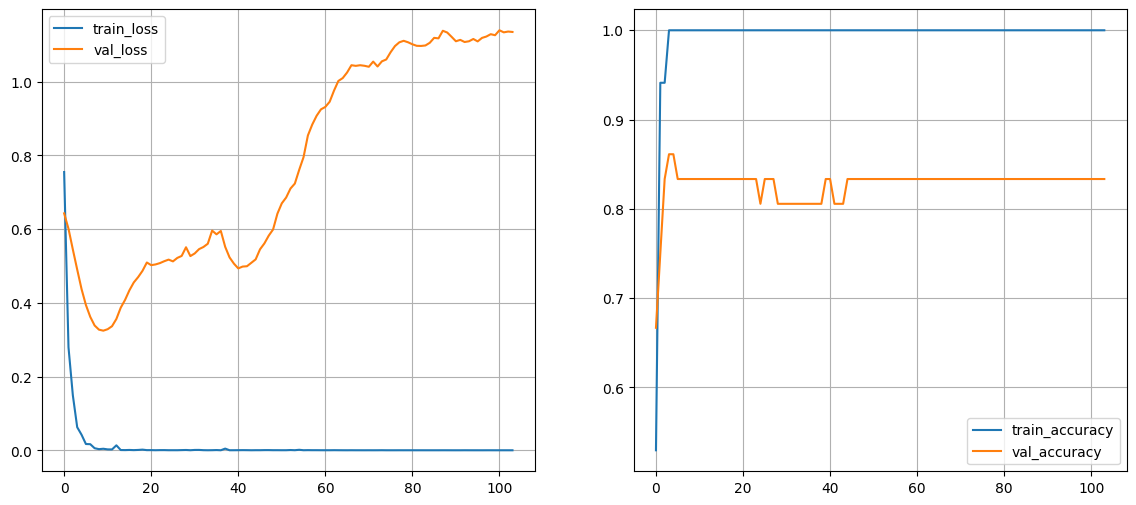

In [51]:
resnet_50_trainer.plot_graphs()

100%|██████████| 12/12 [00:05<00:00,  2.35it/s]


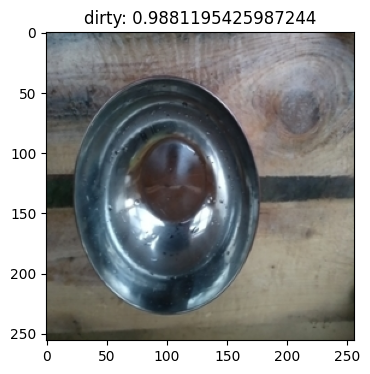

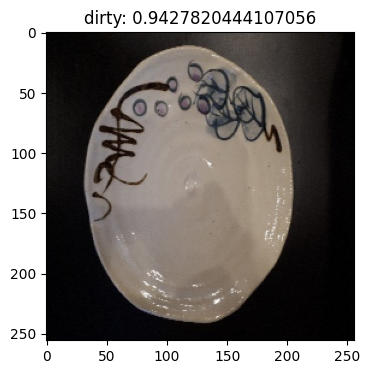

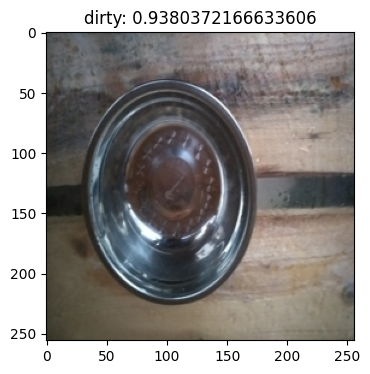

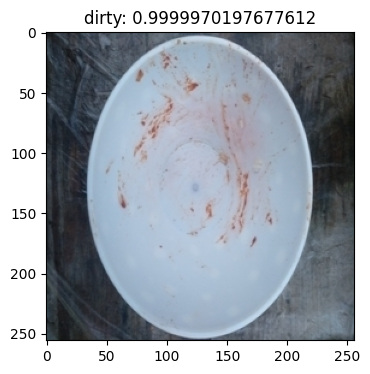

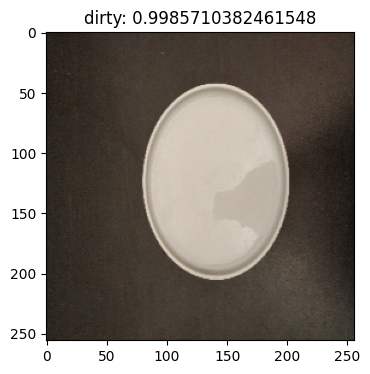

,id,label
594,0000,dirty
255,0001,dirty
538,0002,dirty
640,0003,dirty
616,0004,dirty


In [52]:
y_proba_resnet_50, file_names_resnet_50 = resnet_50_trainer.make_inference(test_data, use_best_model=True)
y_pred_resnet_50 = y_proba_resnet_50.argmax(dim=1).numpy()
# mapping to our class labels
test_pred_resnet_50 = np.where(y_pred_resnet_50 < 0.5, 'cleaned', 'dirty')

submission_resnet_50 = make_df(test_pred_resnet_50, file_names_resnet_50)

submission_resnet_50.head()

In [53]:
submission_resnet_50.to_csv('submission_resnet_50.csv', index=False)

We have the best accuracy = 0.89381 with ResNet-50.

**5.4 EfficientNet**

In [54]:
eff_net = models.efficientnet_b3(weights='DEFAULT')

# eff_net.classifier - Dropout and FC layer
eff_net.classifier

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 170MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
)

In [55]:
# EfficientNet preprocessing operations
eff_net_transforms = models.EfficientNet_B3_Weights.IMAGENET1K_V1.transforms

eff_net_transforms

functools.partial(<class 'torchvision.transforms._presets.ImageClassification'>, crop_size=300, resize_size=320, interpolation=<InterpolationMode.BICUBIC: 'bicubic'>)

In [56]:

# def objective(trial):
#     optimizer_name = trial.suggest_categorical('optimizer_name', ['Adam', 'SGD'])
#     lr = trial.suggest_float('lr', 1e-4, 1e-3)
    
#     momentum = None
#     amsgrad = None
#     if optimizer_name == 'SGD':
#         momentum = trial.suggest_float('momentum', 0.8, 0.99)
#     elif optimizer_name == 'Adam':
#         amsgrad = trial.suggest_categorical('amsgrad', [True, False])

#     # scheduler parameters
#     # scheduler_params = {'step_size': trial.suggest_int('step_size', 10, 40, step=10),
#     #                     'gamma': trial.suggest_float('gamma', 0.1, 0.9)}

#     # model creation
#     eff_net = models.efficientnet_b3(weights='DEFAULT')
#     # disable grad for all layers
#     eff_net.requires_grad = False
#     # we need to get 2 classes output instead 1000 (eff_net.classifier - Dropout and FC layer)
#     # the following code doesn't work for some reason, so we use the version with Sequential
#     # eff_net.classifier[-1].out_features = 2
#     n_features = eff_net.classifier[-1].in_features
#     eff_net.classifier = nn.Sequential(nn.Dropout(p=0.3, inplace=True),
#                                        nn.Linear(n_features, 2, bias=True))
#     # we need to enable grad for FC layer
#     eff_net.classifier.requires_grad = True
#     eff_net = eff_net.to(device)

#     if optimizer_name == 'Adam':
#         eff_net_trainer = Model_Trainer(eff_net, epochs=1, early_stopping_rounds=False, logging=False,
#                                         optimizer=optim.Adam(eff_net.parameters(), lr=lr, amsgrad=amsgrad))
#     elif optimizer_name == 'SGD':
#          eff_net_trainer = Model_Trainer(eff_net, epochs=1, early_stopping_rounds=False, logging=False,
#                                          optimizer=optim.SGD(eff_net.parameters(), lr=lr, momentum=momentum))

#     epochs = 30
#     for _e in range(1, epochs + 1):
#         eff_net, eff_net_accuracy = eff_net_trainer.train(train_data, val_data)

#         # passes the intermediate accuracy value to Optuna, associating it with the current step number (epoch)
#         trial.report(eff_net_accuracy, _e)
        
#         # early stop if worst result
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
            
#     return eff_net_accuracy


# study = optuna.create_study(direction='maximize', study_name='EfficientNet-B3',
#                             pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10)
#                            )
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# eff_net_optuna_score = study.best_value
# eff_net_optuna_params = study.best_params

In [57]:
# eff_net_optuna_params

In [58]:
params = {'optimizer_name': 'Adam', 'lr': 0.0009735738975784971, 'amsgrad': False}

eff_net = models.efficientnet_b3(weights='DEFAULT')
eff_net.requires_grad = False
n_features = eff_net.classifier[-1].in_features
eff_net.classifier = nn.Sequential(nn.Dropout(p=0.3, inplace=True),
                                   nn.Linear(n_features, 2, bias=True))
eff_net.classifier.requires_grad = True
eff_net = eff_net.to(device)

eff_net_trainer = Model_Trainer(eff_net, epochs=400, early_stopping_rounds=100,
                                optimizer=optim.Adam(eff_net.parameters(), lr=0.0009735738975784971, amsgrad=False),
                                logging=True)
eff_net, eff_net_accuracy = eff_net_trainer.train(train_data, val_data)

Epoch [1/400], loss_mean_train=0.672
Epoch [1/400], loss_mean_val=0.737, accuracy_val=0.6388888888888888
Epoch [2/400], loss_mean_train=0.527
Epoch [2/400], loss_mean_val=0.741, accuracy_val=0.7222222222222222
Epoch [3/400], loss_mean_train=0.360
Epoch [3/400], loss_mean_val=0.711, accuracy_val=0.7222222222222222
Epoch [4/400], loss_mean_train=0.220
Epoch [4/400], loss_mean_val=0.644, accuracy_val=0.75
Epoch [5/400], loss_mean_train=0.113
Epoch [5/400], loss_mean_val=0.629, accuracy_val=0.75
Epoch [6/400], loss_mean_train=0.056
Epoch [6/400], loss_mean_val=0.768, accuracy_val=0.75
Epoch [7/400], loss_mean_train=0.029
Epoch [7/400], loss_mean_val=1.021, accuracy_val=0.75
Epoch [8/400], loss_mean_train=0.021
Epoch [8/400], loss_mean_val=1.349, accuracy_val=0.7222222222222222
Epoch [9/400], loss_mean_train=0.006
Epoch [9/400], loss_mean_val=1.695, accuracy_val=0.6944444444444444
Epoch [10/400], loss_mean_train=0.004
Epoch [10/400], loss_mean_val=2.048, accuracy_val=0.6944444444444444
Epoc

In [59]:
eff_net_trainer.best_score

0.8333333333333334

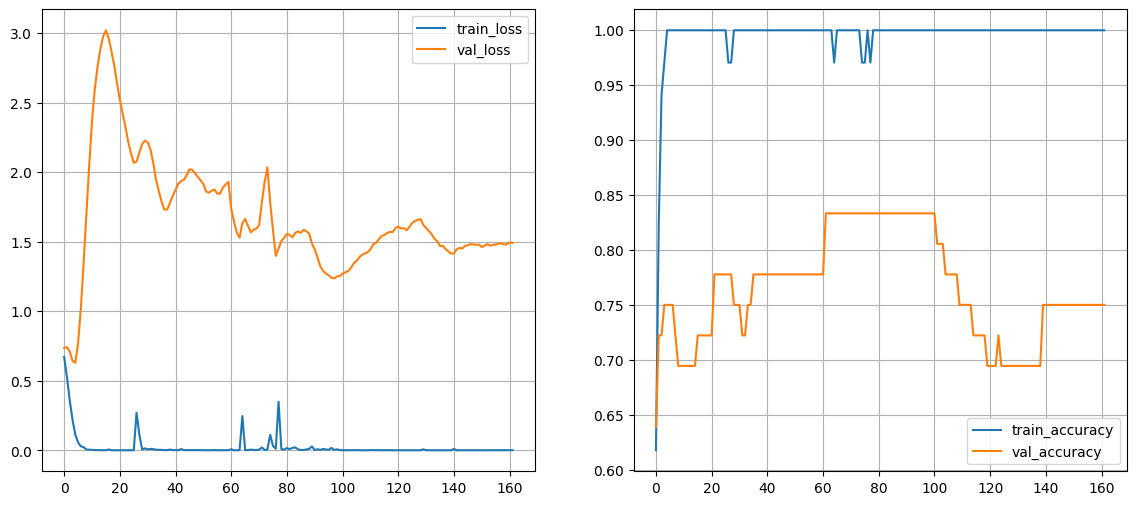

In [60]:
eff_net_trainer.plot_graphs()

100%|██████████| 12/12 [00:04<00:00,  2.61it/s]


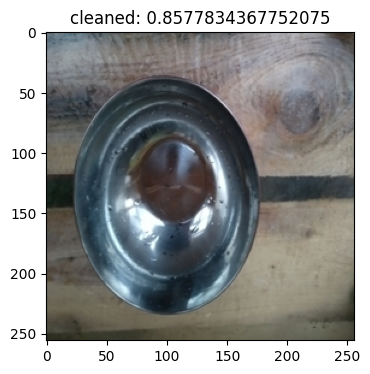

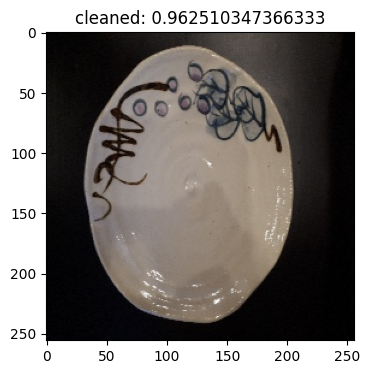

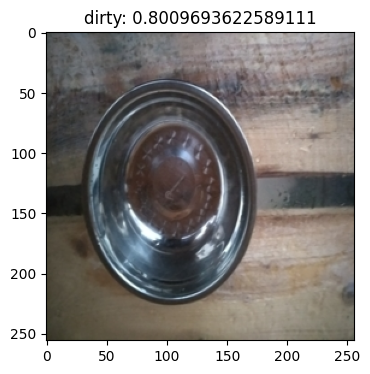

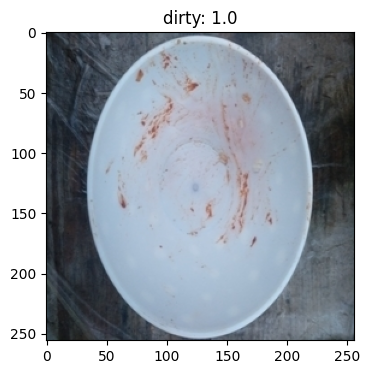

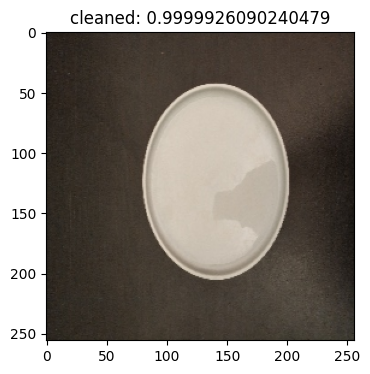

,id,label
594,0000,dirty
255,0001,dirty
538,0002,dirty
640,0003,dirty
616,0004,dirty


In [61]:
y_proba_eff_net, file_names_eff_net = eff_net_trainer.make_inference(test_data, use_best_model=True)
y_pred_eff_net = y_proba_eff_net.argmax(dim=1).numpy()
# mapping to our class labels
test_pred_eff_net = np.where(y_pred_eff_net < 0.5, 'cleaned', 'dirty')

submission_eff_net = make_df(test_pred_eff_net, file_names_eff_net)

submission_eff_net.head()

In [62]:
submission_eff_net.to_csv('submission_eff_net.csv', index=False)

We have the best accuracy = 0.90725 with EfficientNet-B3.

Let's save model weights:

In [63]:
eff_net_weights = eff_net.state_dict()
torch.save(eff_net_weights, 'eff_net_weights.tar')

**5.5 Semi-supervised learning (self-training)**

Now we can take the output from one of our models with a good result and use it to train on the test dataset. This allows us to improve accuracy.

1. We only use model's predictions with at least 95% confidence (for example). We will add such images to the original training set.
2. We can use Test-Time Augmentation (TTA): create several augmented versions of a single test image and feed them into the model. If the model produces the same class for all augmentations and the average confidence is high, add that image.
3. It's possible to reduce the weight of new samples (optional).
4. We can perform several of these iterations.

In [64]:
# dataframe for results
# submission_eff_net - prediction for the original images
submission_eff_net = submission_eff_net.set_index('id')
df_augm = submission_eff_net.copy()

df_augm.head()

,label
id,
0000,dirty
0001,dirty
0002,dirty
0003,dirty
0004,dirty


In [65]:
# transforms for TTA
test_transforms = tfs.Compose([tfs.RandomHorizontalFlip(p=0.5),
                               tfs.RandomVerticalFlip(p=0.5),
                               tfs.RandomAffine(degrees=15),
                               tfs.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                               tfs.Resize((256, 256)),
                               tfs.ToImage(),
                               tfs.ToDtype(torch.float32, scale=True),
                               tfs.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                              ])

# predictions for the augmenting images (2 iterations)
for i in range(1, 3):
    d_test_augm = MyDataset(test_path, class_names=class_names, train=False,
                            transform=test_transforms)
    test_data_augm = data.DataLoader(d_test_augm, batch_size=batch_size, shuffle=False, drop_last=False)

    y_proba_augm, file_names_augm = eff_net_trainer.make_inference(test_data_augm, use_best_model=True, show_img=False)
    df_current = pd.DataFrame({'id': file_names_augm, f'proba_0_iter{i}': y_proba_augm[:, 0], f'proba_1_iter{i}': y_proba_augm[:, 1]})
    df_current['id'] = df_current['id'].str.replace('.jpg', '')
    df_current = df_current.set_index('id')

    y_pred_augm = y_proba_augm.argmax(dim=1).numpy()
    test_pred_augm = np.where(y_pred_augm < 0.5, 'cleaned', 'dirty')
    df_current[f'label_iter{i}'] = test_pred_augm
    # at each iteration, the batches will be different, we combine dataframes by indices
    df_augm = df_augm.join(df_current)

100%|██████████| 12/12 [00:11<00:00,  1.07it/s]


In [66]:
df_current.head()

,proba_0_iter2,proba_1_iter2,label_iter2
id,,,
0365,0.412450,0.587550,dirty
0440,0.000002,0.999998,dirty
0369,0.000002,0.999998,dirty
0624,0.000260,0.999740,dirty
0285,0.999949,0.000051,cleaned


In [67]:
df_augm.head()

,label,proba_0_iter1,proba_1_iter1,label_iter1,proba_0_iter2,proba_1_iter2,label_iter2
id,,,,,,,
0000,dirty,7.805765e-08,1.000000,dirty,7.775369e-07,0.999999,dirty
0001,dirty,1.196255e-03,0.998804,dirty,5.511777e-04,0.999449,dirty
0002,dirty,7.147197e-08,1.000000,dirty,6.279932e-07,0.999999,dirty
0003,dirty,3.979723e-07,1.000000,dirty,1.454325e-06,0.999999,dirty
0004,dirty,3.908822e-03,0.996091,dirty,6.482714e-03,0.993517,dirty


Ideally, the dataframe should also include probabilities for the original images without augmentations, but we'll do without that for now.

In [68]:
threshold = 0.95
mask = (df_augm['label'] == df_augm['label_iter1']) & \
       (df_augm['label_iter1'] == df_augm['label_iter2']) & \
       (
       ((df_augm['proba_0_iter1'] > threshold) & (df_augm['proba_0_iter2'] > threshold)) | \
       ((df_augm['proba_1_iter1'] > threshold) & (df_augm['proba_1_iter2'] > threshold))
       )

df_res = df_augm[mask]
df_res

,label,proba_0_iter1,proba_1_iter1,label_iter1,proba_0_iter2,proba_1_iter2,label_iter2
id,,,,,,,
0000,dirty,7.805765e-08,1.000000,dirty,7.775369e-07,0.999999,dirty
0001,dirty,1.196255e-03,0.998804,dirty,5.511777e-04,0.999449,dirty
0002,dirty,7.147197e-08,1.000000,dirty,6.279932e-07,0.999999,dirty
0003,dirty,3.979723e-07,1.000000,dirty,1.454325e-06,0.999999,dirty
0004,dirty,3.908822e-03,0.996091,dirty,6.482714e-03,0.993517,dirty
...,...,...,...,...,...,...,...
0738,dirty,4.993212e-06,0.999995,dirty,2.020310e-05,0.999980,dirty
0739,dirty,2.484799e-04,0.999752,dirty,5.065089e-04,0.999493,dirty
0740,dirty,7.622147e-04,0.999238,dirty,3.270245e-04,0.999673,dirty


In [69]:
idx = df_res.index
img_names_ssl = [f'{i}.jpg' for i in idx]

# the required file names
print(img_names_ssl[:5])
print(len(img_names_ssl))

['0000.jpg', '0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg']
602


In [70]:
# sorted by id, the model predictions that will be used as class labels
y_pred_ssl = df_res['label'].map({'cleaned': 0, 'dirty': 1}).to_numpy()

y_pred_ssl[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [71]:
class SemiSupervisedDataset(data.Dataset):
    def __init__(self, path, class_names, img_names, y_pred, transform=None):
        self.path = path
        self.class_names = class_names
        self.img_names = img_names
        self.y_pred = y_pred
        self.transform = transform
        
        # one-hot vectors
        self.targets = torch.eye(len(self.class_names))
        self.files = []
        # add only files that are in img_names
        for i in os.listdir(os.path.join(self.path)):
            if i in self.img_names:
                self.files.append(i)

        # we need to sort the file names to match y_pred      
        self.files = sorted(self.files)
        self.length = len(self.files)

    def __getitem__(self, item):
        path_file, target = os.path.join(self.path, self.files[item]), self.y_pred[item]
        img = Image.open(path_file)
        y = self.targets[target]

        if self.transform:
            img = self.transform(img)
        return img, y

    def __len__(self):
        return self.length


d_train_semi = SemiSupervisedDataset(test_path, class_names=class_names, img_names=img_names_ssl,
                                     y_pred=y_pred_ssl, transform=train_transforms)
batch_size = 64
train_data_semi = data.DataLoader(d_train_semi, batch_size=batch_size, shuffle=True, drop_last=False)
X_batch, y_batch = next(iter(train_data_semi))

print(X_batch.shape, y_batch.shape)
print(len(train_data_semi))

torch.Size([64, 3, 256, 256]) torch.Size([64, 2])
10


In [72]:
d_train_semi.files[:5]

['0000.jpg', '0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg']

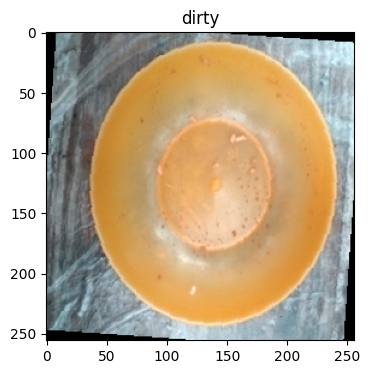

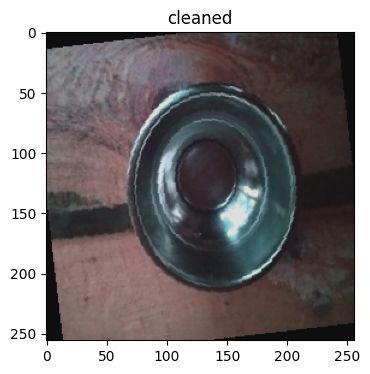

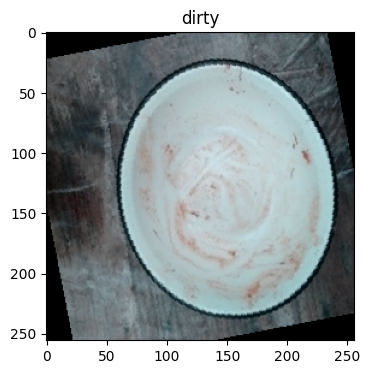

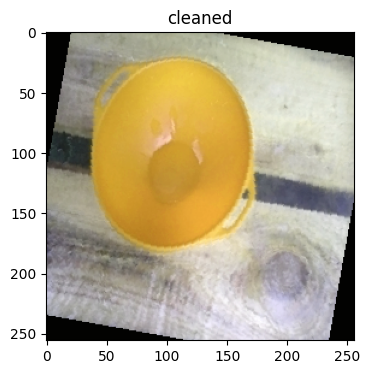

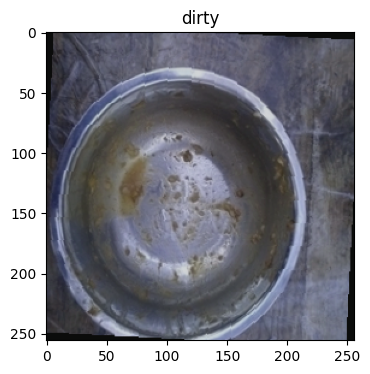

In [73]:
show_img(X_batch, y_batch)

Now we can start retraining the existing model on the test sample, taking into account its own predictions.

It is important to understand that the validation used may not always work correctly, since the training set now contains errors.

In [74]:
# params = {'optimizer_name': 'Adam', 'lr': 0.0009735738975784971, 'amsgrad': False}

# # we pass an existing model with trained weights
# eff_net_trainer_semi = Model_Trainer(eff_net, epochs=200, early_stopping_rounds=50,
#                                      optimizer=optim.Adam(eff_net.parameters(), lr=0.0009735738975784971, amsgrad=False),
#                                      logging=True)
# eff_net_semi, eff_net_accuracy_semi = eff_net_trainer_semi.train(train_data_semi, val_data)

In [75]:
# eff_net_trainer_semi.best_score

In [76]:
# eff_net_trainer_semi.plot_graphs()

In [77]:
# y_proba_eff_net_semi, file_names_eff_net_semi = eff_net_trainer_semi.make_inference(test_data, use_best_model=True)
# y_pred_eff_net_semi = y_proba_eff_net_semi.argmax(dim=1).numpy()
# # mapping to our class labels
# test_pred_eff_net_semi = np.where(y_pred_eff_net_semi < 0.5, 'cleaned', 'dirty')

# submission_eff_net_semi = make_df(test_pred_eff_net_semi, file_names_eff_net_semi)

# submission_eff_net_semi.head()

In [78]:
# submission_eff_net_semi.to_csv('submission_eff_net_semi.csv', index=False)

And we get accuracy = 0.92607 after semi-supervised learning, though with the same model result was 0.86827.


**Conclusions**

**We achieved good accuracy with a very small training set, in part due to semi-supervised learning. One way to improve the results is to use autoencoders to extract significant features from the test set. The use of ensembles can also be considered.**